# Importación de las librerías necesarias para la ejecución #

In [8]:
#Librerias Necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import keras
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense
from keras import backend as K

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
#from sklearn.preprocessing import scale

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SelectFromModel

from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import confusion_matrix

# Lectura de los datos de los partidos ya formateados en .csv

In [9]:
import os

dataframe_equipos = pd.read_csv("teams.csv")

dataframes = []
carpeta = "Datos_Formateados/"  # Reemplaza "ruta/de/la/carpeta" con la ruta de la carpeta que deseas explorar

archivos = os.listdir(carpeta)
for archivo in archivos:
    df = pd.read_csv("Datos_Formateados/"+archivo)
    df = df.iloc[::-1]
    dataframes.append(df)
datos_partidos = pd.concat(dataframes, ignore_index=True)
datos_partidos.shape

(25266, 22)

In [10]:
datos_partidos = datos_partidos.dropna()
datos_partidos.shape

(25266, 22)

In [11]:
datos_partidos.head()

,Unnamed: 0,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,...,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS
0,17903,2004-10-22,10400066,Final,1610612750,1610612752,2004,1610612750,102.0,0.523,...,32.0,46.0,1610612752,82.0,0.333,0.778,0.154,21.0,41.0,1
1,17902,2004-10-22,10400067,Final,1610612762,1610612758,2004,1610612762,103.0,0.507,...,25.0,43.0,1610612758,88.0,0.362,0.814,0.250,16.0,33.0,1
2,17901,2004-10-22,10400065,Final,1610612766,1610612757,2004,1610612766,69.0,0.377,...,24.0,36.0,1610612757,63.0,0.311,0.741,0.217,9.0,44.0,1
3,17900,2004-10-22,10400068,Final,1610612738,1610612751,2004,1610612738,83.0,0.431,...,14.0,34.0,1610612751,96.0,0.449,0.885,0.231,21.0,35.0,0
4,17899,2004-10-22,10400071,Final,1610612765,1610612764,2004,1610612765,100.0,0.549,...,24.0,34.0,1610612764,82.0,0.411,0.724,0.071,15.0,33.0,1


In [12]:
def get_equipos(dataframe: pd.DataFrame) -> list:
    equipos = dataframe["HOME_TEAM_ID"].drop_duplicates()
    return equipos

def get_nombres_equipo(lista_ids: list, dataframe_equipos: pd.DataFrame) -> list:
    list = []
    for equipo in lista_ids:
        list.append(dataframe_equipos.loc[dataframe_equipos['TEAM_ID'] == equipo, 'NICKNAME'].values[0])
    return list

equipos_ids = get_equipos(dataframe=datos_partidos)
equipos_nombres = get_nombres_equipo(lista_ids=equipos_ids, dataframe_equipos=dataframe_equipos)
len(equipos_nombres)

30

# Predicción del ganador de un partido 

## - Pre-procesamiento de los datos ##

### Limpiado de valores de la columna FTR diferentes a [A,D,H]

In [13]:
condicion = (datos_partidos['HOME_TEAM_WINS'] != 1) & (datos_partidos['HOME_TEAM_WINS'] != 0)
datos_partidos = datos_partidos.drop(datos_partidos[condicion].index)

### Obtención del gol average medio de cada partido

In [14]:
def get_partidos_jugados_por_equipo(dataframe: pd.DataFrame, equipo: str) -> int:
    partidos_jugados_local = len(dataframe.loc[dataframe['HOME_TEAM_ID'] == equipo])
    partidos_jugados_visitante = len(dataframe.loc[dataframe['VISITOR_TEAM_ID'] == equipo])
    return partidos_jugados_local + partidos_jugados_visitante

def get_puntos_encestados_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_puntos_por_partido = []
    partidos_del_equipo = dataframe.loc[(dataframe['HOME_TEAM_ID'] == equipo) | (dataframe['VISITOR_TEAM_ID'] == equipo)]
    for idx, partido in partidos_del_equipo.iterrows():
        if partido['HOME_TEAM_ID'] == equipo:
            lista_puntos_por_partido.append(partido['PTS_home'])
        if partido['VISITOR_TEAM_ID'] == equipo:
            lista_puntos_por_partido.append(partido['PTS_away'])
    return lista_puntos_por_partido

def get_puntos_recibidos_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_puntos_por_partido = []
    partidos_del_equipo = dataframe.loc[(dataframe['HOME_TEAM_ID'] == equipo) | (dataframe['VISITOR_TEAM_ID'] == equipo)]
    for idx, partido in partidos_del_equipo.iterrows():
        if partido['HOME_TEAM_ID'] == equipo:
            lista_puntos_por_partido.append(partido['PTS_away'])
        if partido['VISITOR_TEAM_ID'] == equipo:
            lista_puntos_por_partido.append(partido['PTS_home'])
    return lista_puntos_por_partido

def get_media_puntos_encestados_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_puntos_por_partido = get_puntos_encestados_por_partido(dataframe=dataframe, equipo=equipo)
    #lista_puntos_por_partido = lista_puntos_por_partido[::-1]
    lista_media_puntos_por_partido = []
    puntos_acumulados = 0
    for idx, valor in enumerate(lista_puntos_por_partido):
        lista_media_puntos_por_partido.append((valor + puntos_acumulados) / (idx+1))
        puntos_acumulados += valor
    return lista_media_puntos_por_partido

def get_media_puntos_recibidos_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_puntos_por_partido = get_puntos_recibidos_por_partido(dataframe=dataframe, equipo=equipo)
    #lista_puntos_por_partido = lista_puntos_por_partido[::-1]
    lista_media_puntos_por_partido = []
    puntos_acumulados = 0
    for idx, valor in enumerate(lista_puntos_por_partido):
        lista_media_puntos_por_partido.append((valor + puntos_acumulados) / (idx+1))
        puntos_acumulados += valor
    return lista_media_puntos_por_partido

def get_basket_average_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_puntos_encestados_por_partido = get_media_puntos_encestados_por_partido(dataframe=dataframe, equipo=equipo)
    lista_puntos_recibidos_por_partido = get_media_puntos_recibidos_por_partido(dataframe=dataframe, equipo=equipo)
    #lista_puntos_encestados_por_partido = lista_puntos_encestados_por_partido[::-1]
    #lista_puntos_recibidos_por_partido = lista_puntos_recibidos_por_partido[::-1]
    lista_basket_average_por_partido = []
    for idx, valor in enumerate(lista_puntos_encestados_por_partido):
        lista_basket_average_por_partido.append(valor - lista_puntos_recibidos_por_partido[idx])
    return lista_basket_average_por_partido

def get_media_basket_average_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_media_puntos_encestados_por_partido = get_media_puntos_encestados_por_partido(dataframe=dataframe, equipo=equipo)
    lista_media_puntos_recibidos_por_partido = get_media_puntos_recibidos_por_partido(dataframe=dataframe, equipo=equipo)
    lista_media_basket_average_por_partido = []
    for idx, valor in enumerate(lista_media_puntos_encestados_por_partido):
        lista_media_basket_average_por_partido.append((valor - lista_media_puntos_recibidos_por_partido[idx]))
    return lista_media_basket_average_por_partido

def obtencion_basket_average_dataframe(dataframe: pd.DataFrame, guardar: bool) -> list:
    lista_listas_basket_average_medio_cada_equipo = []
    equipos = get_equipos(dataframe=dataframe)
    for equipo in equipos:
        lista_basket_average_medio_un_equipo = get_media_basket_average_por_partido(dataframe=dataframe, equipo=equipo)
        lista_basket_average_medio_un_equipo.insert(0,0)
        if guardar:
            dict_ultimo_basket_average_equipo[equipo] = lista_basket_average_medio_un_equipo[-1]
        lista_basket_average_medio_un_equipo.pop()
        lista_listas_basket_average_medio_cada_equipo.append(lista_basket_average_medio_un_equipo)
    return lista_listas_basket_average_medio_cada_equipo
        
def get_diferencia_media_basket_average_por_partido(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_media_basket_average_por_partido = get_media_basket_average_por_partido(dataframe=dataframe, equipo=equipo)
    lista_diferencias = []
    valor_anterior = 0
    for valor in lista_media_basket_average_por_partido:
        lista_diferencias.append(valor - valor_anterior)
        valor_anterior = valor
    return lista_diferencias

def obtencion_diferencias_average_dataframe(dataframe: pd.DataFrame, guardar: bool) -> list:
    lista_listas_diferencias_basket_average_medio_cada_equipo = []
    equipos = get_equipos(dataframe=dataframe)
    for equipo in equipos:
        lista_diferencias_basket_average_medio_un_equipo = get_diferencia_media_basket_average_por_partido(dataframe=dataframe, equipo=equipo)
        lista_diferencias_basket_average_medio_un_equipo.insert(0,0)
        if guardar:
            dict_ultimas_diferencias_cada_equipo[equipo] = lista_diferencias_basket_average_medio_un_equipo[-1]
        lista_diferencias_basket_average_medio_un_equipo.pop()
        lista_listas_diferencias_basket_average_medio_cada_equipo.append(lista_diferencias_basket_average_medio_un_equipo)
    return lista_listas_diferencias_basket_average_medio_cada_equipo

def get_puntos_en_liga_equipo(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_puntos_por_partido = []
    puntos = 0
    partidos_equipo = dataframe.loc[(dataframe['HOME_TEAM_ID'] == equipo) | (dataframe['VISITOR_TEAM_ID'] == equipo)]
    for idx, partido in partidos_equipo.iterrows():
        resultado = partido['HOME_TEAM_WINS']
        if partido['HOME_TEAM_ID'] == equipo and resultado == 1:
           puntos += 2 
        elif partido['VISITOR_TEAM_ID'] == equipo and resultado == 0:
           puntos += 2
        else:
            puntos += 1
        lista_puntos_por_partido.append(puntos)
    return lista_puntos_por_partido

def get_resultados_partidos_equipo(dataframe: pd.DataFrame, equipo: str) -> list:
    lista_resultados_equipo = []
    victorias = 0
    derrotas = 0
    partidos_del_equipo = dataframe.loc[(dataframe['HOME_TEAM_ID'] == equipo) | (dataframe['VISITOR_TEAM_ID'] == equipo)]
    for idx, partido in partidos_del_equipo.iterrows():
        if partido['HOME_TEAM_ID'] == equipo and partido['HOME_TEAM_WINS'] == 1:
            victorias += 1
        elif partido['VISITOR_TEAM_ID'] == equipo and partido['HOME_TEAM_WINS'] == 0:
            victorias += 1
        else:
            derrotas += 1
        lista_resultados_equipo.append((victorias,derrotas))
    return lista_resultados_equipo

def obtencion_resultados_en_liga(dataframe: pd.DataFrame, guardar: bool) -> list:
    lista_listas_resultados_en_liga = []
    equipos = get_equipos(dataframe=dataframe)
    for equipo in equipos:
        lista_resultados_por_partido_un_equipo = get_resultados_partidos_equipo(dataframe=dataframe, equipo=equipo)
        lista_resultados_por_partido_un_equipo.insert(0,(0,0))
        if guardar:
            dict_ultimos_resultados_cada_equipo[equipo] = lista_resultados_por_partido_un_equipo[-1]
        lista_resultados_por_partido_un_equipo.pop()
        lista_listas_resultados_en_liga.append(lista_resultados_por_partido_un_equipo)
    return lista_listas_resultados_en_liga

def obtencion_puntos_en_liga(dataframe: pd.DataFrame, guardar:bool) -> list:
    lista_listas_puntos_en_liga = []
    equipos = get_equipos(dataframe=dataframe)
    for equipo in equipos:
        lista_puntos_por_partido_un_equipo = get_puntos_en_liga_equipo(dataframe=dataframe, equipo=equipo)
        lista_puntos_por_partido_un_equipo.insert(0,0)
        if guardar:
            dict_ultimos_puntos_cada_equipo[equipo] = lista_puntos_por_partido_un_equipo[-1]
        lista_puntos_por_partido_un_equipo.pop()
        lista_listas_puntos_en_liga.append(lista_puntos_por_partido_un_equipo)
    return lista_listas_puntos_en_liga
    
def obtencion_media_puntos_encestados(dataframe: pd.DataFrame, guardar:bool) -> list:
    lista_listas_puntos_marcados = []
    equipos = get_equipos(dataframe=dataframe)
    for equipo in equipos:
        lista_puntos_por_partido_un_equipo = get_media_puntos_encestados_por_partido(dataframe=dataframe, equipo=equipo)
        lista_puntos_por_partido_un_equipo.insert(0,0)
        if guardar:
            dict_ultimos_puntos_marcados_cada_equipo[equipo] = lista_puntos_por_partido_un_equipo[-1]
        lista_puntos_por_partido_un_equipo.pop()
        lista_listas_puntos_marcados.append(lista_puntos_por_partido_un_equipo)
    return lista_listas_puntos_marcados

def get_mejores_anotadores(dataframe: pd.DataFrame):
    games_details = pd.read_csv("games_details.csv")
    lista_equipos_ya_vistos = []
    pass
    
def insercion_datos_cada_dataframe(dataframe: pd.DataFrame, lista_listas_basket_average_medio_cada_equipo: list, lista_listas_diferencias_basket_average_medio_cada_equipo: list, 
lista_listas_puntos_por_partido: list, lista_listas_puntos_marcados_por_partido: list,
lista_listas_resultados_por_partido: list):
    equipos = get_equipos(dataframe=dataframe)
    for idx_equipos,equipo in enumerate(equipos):
        partidos_del_equipo = dataframe.loc[(dataframe['HOME_TEAM_ID'] == equipo) | (dataframe['VISITOR_TEAM_ID'] == equipo)]
        idx_partidos = 0
        for idx, partido in partidos_del_equipo.iterrows():
            if partido['HOME_TEAM_ID'] == equipo:
                dataframe.at[idx,'Basket_Average_Home'] = lista_listas_basket_average_medio_cada_equipo[idx_equipos][idx_partidos]
                dataframe.at[idx,'Dif_Home'] = lista_listas_diferencias_basket_average_medio_cada_equipo[idx_equipos][idx_partidos]
                dataframe.at[idx,'Puntos_Home'] = lista_listas_puntos_por_partido[idx_equipos][idx_partidos]
                dataframe.at[idx,'Puntos_Encestados_Home'] = lista_listas_puntos_marcados_por_partido[idx_equipos][idx_partidos]
                dataframe.at[idx,'Victorias_Home'] = lista_listas_resultados_por_partido[idx_equipos][idx_partidos][0]
                dataframe.at[idx,'Derrotas_Home'] = lista_listas_resultados_por_partido[idx_equipos][idx_partidos][1]
            if partido['VISITOR_TEAM_ID'] == equipo:
                dataframe.at[idx,'Basket_Average_Away'] = lista_listas_basket_average_medio_cada_equipo[idx_equipos][idx_partidos]
                dataframe.at[idx,'Dif_Away'] = lista_listas_diferencias_basket_average_medio_cada_equipo[idx_equipos][idx_partidos]
                dataframe.at[idx,'Puntos_Away'] = lista_listas_puntos_por_partido[idx_equipos][idx_partidos]
                dataframe.at[idx,'Puntos_Encestados_Away'] = lista_listas_puntos_marcados_por_partido[idx_equipos][idx_partidos]
                dataframe.at[idx,'Victorias_Away'] = lista_listas_resultados_por_partido[idx_equipos][idx_partidos][0]
                dataframe.at[idx,'Derrotas_Away'] = lista_listas_resultados_por_partido[idx_equipos][idx_partidos][1]
            idx_partidos += 1
    return dataframe    
    
dict_ultimas_diferencias_cada_equipo = {}    
dict_ultimo_basket_average_equipo = {}
dict_ultimos_puntos_cada_equipo = {}
dict_ultimos_puntos_marcados_cada_equipo = {}
dict_ultimos_resultados_cada_equipo = {}
guardar=False
for idx,temporada in enumerate(dataframes):
    if idx == (len(dataframes) - 1):
        guardar = True
    lista_listas_basket_average_medio_cada_equipo = obtencion_basket_average_dataframe(dataframe=temporada, guardar=guardar)
    lista_listas_diferencias_basket_average_medio_cada_equipo = obtencion_diferencias_average_dataframe(dataframe=temporada, guardar=guardar)
    lista_listas_puntos_por_partido = obtencion_puntos_en_liga(dataframe=temporada, guardar=guardar)
    lista_listas_puntos_marcados_por_partido = obtencion_media_puntos_encestados(dataframe=temporada, guardar=guardar)
    lista_listas_resultados_por_partido = obtencion_resultados_en_liga(dataframe=temporada, guardar=guardar)

    dataframe_con_datos_temporada = insercion_datos_cada_dataframe(dataframe=temporada, lista_listas_basket_average_medio_cada_equipo=lista_listas_basket_average_medio_cada_equipo,
                lista_listas_diferencias_basket_average_medio_cada_equipo=lista_listas_diferencias_basket_average_medio_cada_equipo,
                lista_listas_puntos_por_partido=lista_listas_puntos_por_partido,
                lista_listas_puntos_marcados_por_partido=lista_listas_puntos_marcados_por_partido,
                lista_listas_resultados_por_partido=lista_listas_resultados_por_partido)
    dataframes[idx] = dataframe_con_datos_temporada
    if guardar:
        dataframe_con_datos_temporada.to_csv("ayno.csv")
    
datos_partidos = pd.concat(dataframes)
    
print(dict_ultimos_puntos_marcados_cada_equipo)
print(len(dict_ultimos_puntos_marcados_cada_equipo))

##NO PILLA LOS ULTIMOS DATOS DE TODAS LAS LIGAS

{1610612764: 109.24324324324324, 1610612749: 111.77777777777777, 1610612745: 110.8, 1610612761: 111.64864864864865, 1610612738: 118.75, 1610612744: 116.0, 1610612746: 107.88888888888889, 1610612747: 113.10810810810811, 1610612743: 115.11428571428571, 1610612763: 114.74285714285715, 1610612751: 112.63888888888889, 1610612757: 110.5, 1610612741: 114.4, 1610612748: 108.75675675675676, 1610612752: 114.30555555555556, 1610612760: 114.55555555555556, 1610612755: 111.44117647058823, 1610612766: 109.0, 1610612759: 109.5, 1610612737: 113.94444444444444, 1610612742: 110.51428571428572, 1610612740: 117.11111111111111, 1610612758: 118.23529411764706, 1610612739: 110.4054054054054, 1610612762: 115.41025641025641, 1610612753: 109.08108108108108, 1610612765: 109.8157894736842, 1610612756: 115.11428571428571, 1610612754: 114.71428571428571, 1610612750: 114.91891891891892}
30


### Asignación de etiquetas numéricas a los posibles valores de FTR, HomeTeam y AwayTeam

In [15]:
label_encoder = LabelEncoder()
datos_partidos['labeled Home'] = label_encoder.fit_transform(datos_partidos['HOME_TEAM_ID'])
datos_partidos['labeled Away'] = label_encoder.fit_transform(datos_partidos['VISITOR_TEAM_ID'])

In [16]:
datos_partidos['HOME_TEAM_WINS'].value_counts()

HOME_TEAM_WINS
1    14845
0    10421
Name: count, dtype: int64

In [17]:
datos_locales = datos_partidos.loc[datos_partidos['HOME_TEAM_WINS'] == 1]  # Obtiene los índices de las primeras 100 filas que cumplen la condición
datos_visitantes = datos_partidos.loc[datos_partidos['HOME_TEAM_WINS'] == 0]  # Obtiene los índices de las primeras 100 filas que cumplen la condición
print(len(datos_locales))
print(len(datos_visitantes))

dataframes = [datos_visitantes, datos_locales.head(10500)]
datos_partidos = pd.concat(dataframes)
datos_partidos = datos_partidos.drop_duplicates()
datos_partidos['HOME_TEAM_WINS'].value_counts()


14845
10421


HOME_TEAM_WINS
1    10500
0    10421
Name: count, dtype: int64

### Definición de los predictores y del objetivo de predicción ###
| Variable | Descripción
| :-------- | :-------:
| HomeTeam | Nombre del equipo local
| AwayTeam | Nombre del equipo visitante
| Gol_Average_Home | Gol Average medio del equipo local hasta el partido que se juega
| Gol_Average_Away | Gol Average medio del equipo visitante hasta el partido que se juega
| Dif_Home | Diferencia entre el Gol Average medio del local de los dos últimos partidos
| Dif_Away | Diferencia entre el Gol Average medio del visitante de los dos últimos partidos
| Rojas_Home | Media de rojas del equipo local
| Rojas_Away | Media de rojas del equipo visitante
| FTR | Ganador del partido (Home, Draw, Away)
| target FTR | Ganador del partido (2, 1, 0)

In [18]:
equipos_locales = datos_partidos['labeled Home']
equipos_visitantes = datos_partidos['labeled Away']
basket_average_home = datos_partidos['Basket_Average_Home']
basket_average_away = datos_partidos['Basket_Average_Away']
basket_averages = datos_partidos[['Basket_Average_Home','Basket_Average_Away']]
diferencia_home = datos_partidos['Dif_Home']
diferencia_away = datos_partidos['Dif_Away']
diferencias = datos_partidos[['Dif_Home','Dif_Away']]
puntos_home = datos_partidos['Puntos_Home']
puntos_away = datos_partidos['Puntos_Away']
puntos = datos_partidos[['Puntos_Home','Puntos_Away']]
puntos_encestados_home = datos_partidos['Puntos_Encestados_Home']
puntos_encestados_away = datos_partidos['Puntos_Encestados_Away']
puntos_encestados = datos_partidos[['Puntos_Encestados_Home','Puntos_Encestados_Away']]
victorias = datos_partidos[['Victorias_Home','Victorias_Away']]
derrotas = datos_partidos[['Derrotas_Home','Derrotas_Away']]
columnas_features = ['Basket_Average_Home','Basket_Average_Away','Dif_Home','Dif_Away','Puntos_Home','Puntos_Away','Puntos_Encestados_Home','Puntos_Encestados_Away',
                     'Victorias_Home','Derrotas_Home','Victorias_Away','Derrotas_Away']
features = datos_partidos[columnas_features]
target = datos_partidos['HOME_TEAM_WINS']

In [382]:
#target = to_categorical(target)
#target.shape

## - Normalización de los datos

Ahora mismo, los dos predictores son variables categóricas de tipo string. Estos no pueden ser alimentados directamente al modelo ya que podría ocasionar algún error. Antes deben ser procesados y convertidos a un valor númerico fácilmente interpretable por el modelo. Para lograr esto, utilizo la opción del **One-shot encoding**

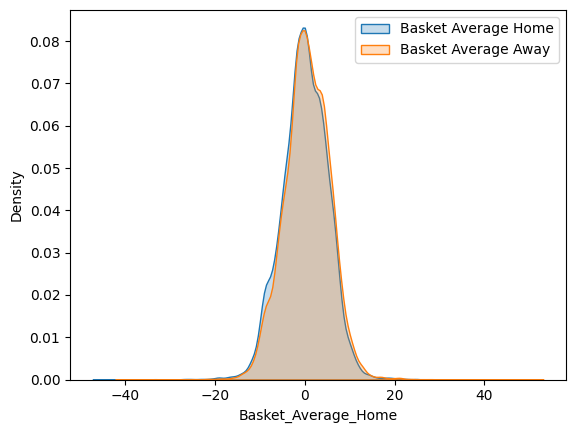

In [19]:
columnas = ['Basket Average Home','Basket Average Away']
for i, col in enumerate(basket_averages.columns):
    sns.kdeplot(basket_averages[col], fill=True, label=columnas[i])
plt.legend()
plt.show()

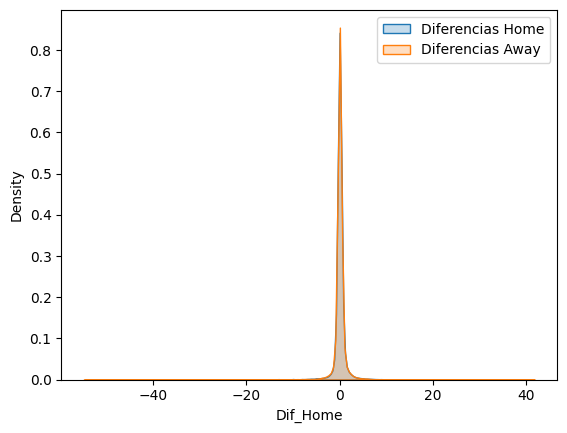

In [14]:
columnas = ['Diferencias Home','Diferencias Away']
for i, col in enumerate(diferencias.columns):
    sns.kdeplot(diferencias[col], fill=True, label=columnas[i])
plt.legend()
plt.show()

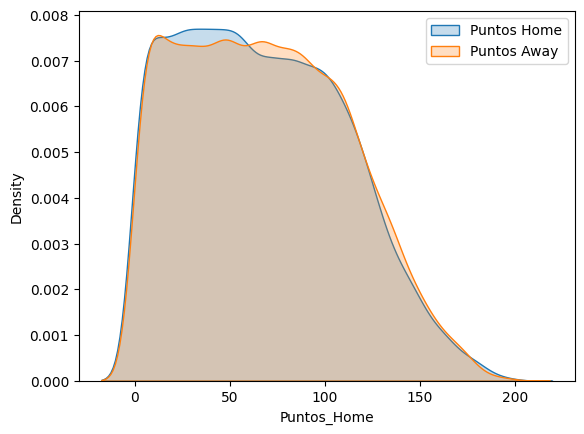

In [15]:
columnas = ['Puntos Home','Puntos Away']
for i, col in enumerate(puntos.columns):
    sns.kdeplot(puntos[col], fill=True, label=columnas[i])
plt.legend()
plt.show()

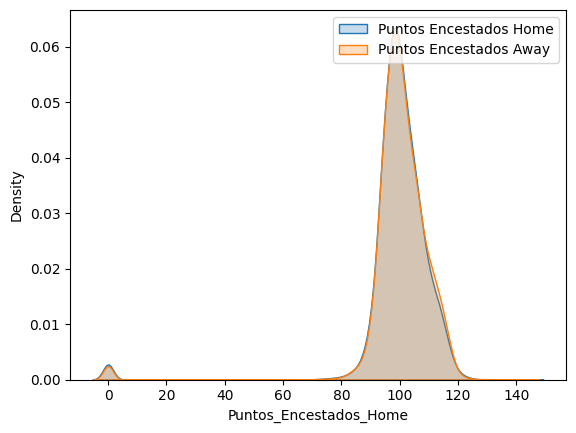

In [16]:
columnas = ['Puntos Encestados Home','Puntos Encestados Away']
for i, col in enumerate(puntos_encestados.columns):
    sns.kdeplot(puntos_encestados[col], fill=True, label=columnas[i])
plt.legend()
plt.show()

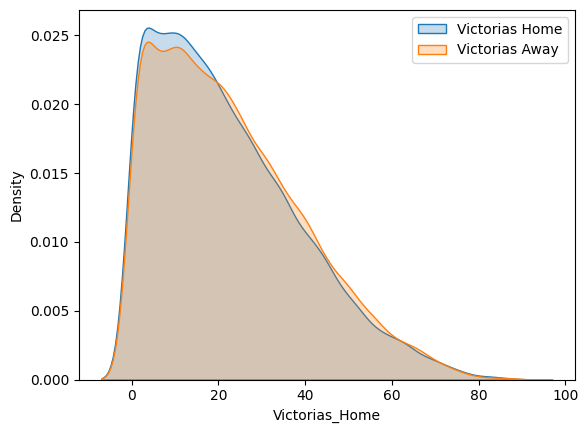

In [17]:
columnas = ['Victorias Home','Victorias Away']
for i, col in enumerate(victorias.columns):
    sns.kdeplot(victorias[col], fill=True, label=columnas[i])
plt.legend()
plt.show()

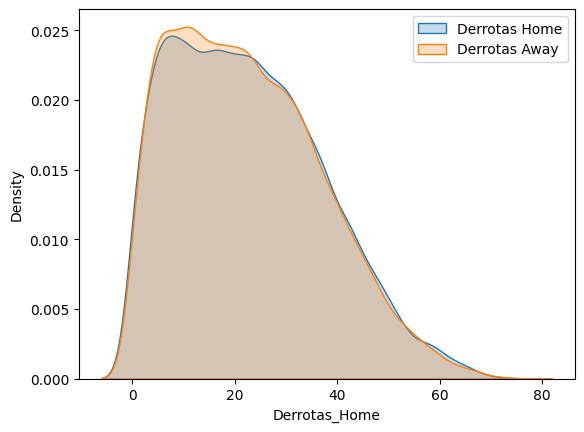

In [18]:
columnas = ['Derrotas Home','Derrotas Away']
for i, col in enumerate(derrotas.columns):
    sns.kdeplot(derrotas[col], fill=True, label=columnas[i])
plt.legend()
plt.show()

In [20]:
scale = MinMaxScaler().fit(features)
features_normalized = scale.transform(features)
features_normalized_dataframe = pd.DataFrame(features_normalized, columns=columnas_features)
features_normalized_dataframe.head()

,Basket_Average_Home,Basket_Average_Away,Dif_Home,Dif_Away,Puntos_Home,Puntos_Away,Puntos_Encestados_Home,Puntos_Encestados_Away,Victorias_Home,Derrotas_Home,Victorias_Away,Derrotas_Away
0,0.523256,0.43956,0.523256,0.43956,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0
1,0.523256,0.43956,0.523256,0.43956,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0
2,0.523256,0.43956,0.523256,0.43956,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0
3,0.755814,0.43956,0.755814,0.43956,0.009852,0.0,0.761194,0.0,0.010989,0.000000,0.0,0.0
4,0.372093,0.43956,0.372093,0.43956,0.004926,0.0,0.619403,0.0,0.000000,0.013514,0.0,0.0


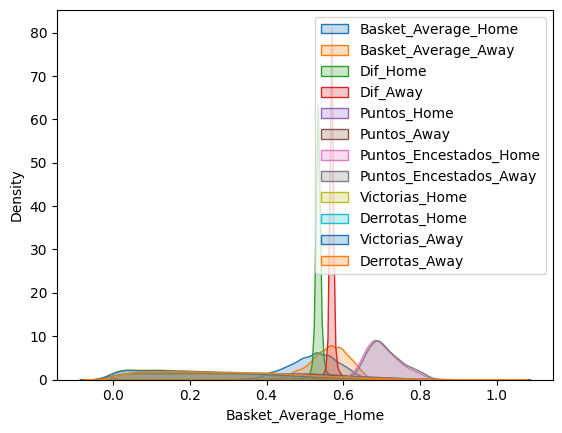

In [20]:
for i, col in enumerate(features_normalized_dataframe.columns):
    sns.kdeplot(features_normalized_dataframe[col], fill=True, label=columnas_features[i])
plt.legend()
plt.show()

In [21]:
onehot_encoder = OneHotEncoder(sparse_output=False)
equipos_encoded = onehot_encoder.fit_transform(np.array([equipos_locales, equipos_visitantes]).T)
equipos_encoded.shape

(20921, 60)

In [22]:
#predictores = np.concatenate([gol_average_home,gol_average_away,diferencia_home,diferencia_away,rojas_home,rojas_away], axis=1)
predictores = np.concatenate((features_normalized_dataframe[columnas_features].values, equipos_encoded), axis=1)

In [23]:
predictores.shape

(20921, 72)

## - Entrenamiento del modelo

### División del dataset en entrenamiento y evaluación del modelo

In [24]:
features_train, features_test, target_train, target_test = train_test_split( predictores, target, test_size=0.2, random_state=42)
print ('Train set:', features_train.shape,  target_train.shape)
print ('Test set:', features_test.shape,  target_test.shape)

Train set: (16736, 72) (16736,)
Test set: (4185, 72) (4185,)


### Definición y construcción del modelo

In [40]:
def get_modelo_regresion():
    model = LogisticRegression(max_iter=3000, solver='sag')
    return model

def get_modelo_random_forest():
    model = RandomForestClassifier(n_estimators=300, random_state=42, max_depth=4, criterion='log_loss')
    return model

def get_modelo_svc():
    model = SVC(kernel='linear', C=0.5, gamma='scale', probability=True)
    return model

def get_modelo_gbm(): ##mejores resultados pero tarda en entrenar
    model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)  
    return model

def get_modelo_decision_tree():
    model = DecisionTreeClassifier(criterion="log_loss",max_depth=13, random_state=42) 
    return model

def get_modelo_knn(): ##mejor recall en empates
    model = KNeighborsClassifier(n_neighbors=47, metric="minkowski", weights='uniform')
    return model

def get_modelo_naive_bayes():
    #model = GaussianNB()
    model = MultinomialNB()
    return model

model = get_modelo_gbm()

### Entrenamiento del modelo

In [41]:
model.fit(features_train, target_train)
#iteraciones=4
#historial_entrenamiento=model.fit(features_train, target_train, validation_data=(features_test,target_test), epochs=iteraciones, verbose=1)

MultinomialNB()

## -Evaluación del modelo

### Evolución del modelo

In [42]:
target_pred = model.predict(features_test)
accuracy = accuracy_score(target_test, target_pred)
recal = recall_score(target_test, target_pred, average=None)
recal_total = recall_score(target_test, target_pred, average='macro')
precision = precision_score(target_test, target_pred, average=None)
precision_total = precision_score(target_test, target_pred, average='macro')
conf_matrix = confusion_matrix(target_test, target_pred)
print("Accuracy del modelo:", accuracy)
print("Recall del modelo:", recal)
print("Recall del modelo:", recal_total)
print("Precision del modelo:", precision)
print("Precision del modelo:", precision_total)
print("Matriz de Confusión:")
print(conf_matrix)

Accuracy del modelo: 0.5933094384707288
Recall del modelo: [0.58470474 0.60169891]
Recall del modelo: 0.5932018290239921
Precision del modelo: [0.58869396 0.59774965]
Precision del modelo: 0.5932218027487848
Matriz de Confusión:
[[1208  858]
 [ 844 1275]]


ValueError: The number of FixedLocator locations (85), usually from a call to set_ticks, does not match the number of labels (7).

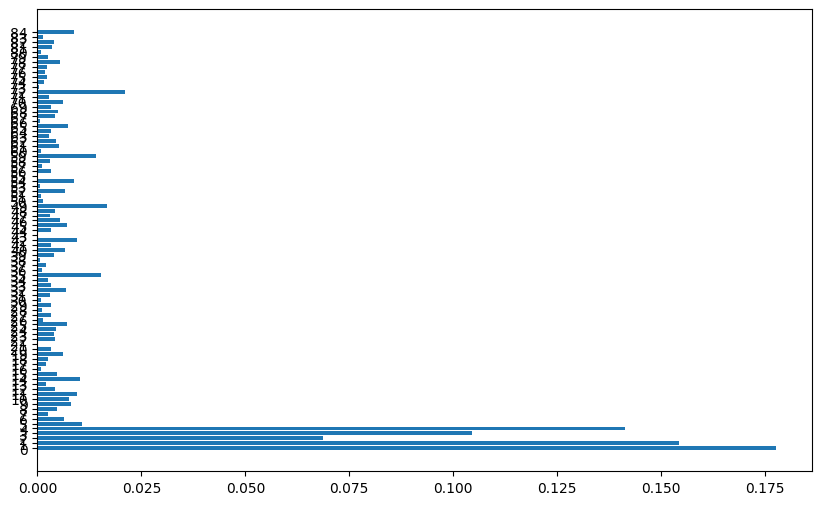

In [273]:
importances = model.feature_importances_

# Obtener nombres de las características
nombres_caracteristicas = ['GAH','GAA','RH','GH','GA','HT','AT']

# Crear un gráfico de barras para visualizar la importancia de las características
plt.figure(figsize=(10, 6))
plt.barh(range(len(importances)), importances, align='center')
plt.yticks(range(len(importances)), nombres_caracteristicas)
plt.xlabel('Importancia de las características')
plt.ylabel('Características')
plt.title('Importancia de las características en Random Forest')
plt.show()

## - Predicción real de un partido

In [142]:
'''
HT='Barcelona'
AT='Malaga'
datos_partido_a_predecir=datos_partidos.loc[(datos_partidos['HomeTeam']==HT) & (datos_partidos['AwayTeam']==AT)]
print(datos_partido_a_predecir.shape)
print(datos_partido_a_predecir)
'''
HT='Real Madrid'
AT='Osasuna'
gol_average_home = dict_ultimo_gol_average_equipo[HT]
gol_average_away = dict_ultimo_gol_average_equipo[AT]
dif_home = dict_ultimas_diferencias_cada_equipo[HT]
dif_away = dict_ultimas_diferencias_cada_equipo[AT]
rojas_home = dict_ultimas_rojas_cada_equipo[HT]
rojas_away = dict_ultimas_rojas_cada_equipo[AT]

### Normalizar los predictores teniendo en cuenta los predictores usados para el entrenamiento del modelo

In [143]:
local = [HT,]
visitante = [AT,]
locales_encoded = label_encoder.transform(local)
visitantes_encoded = label_encoder.transform(visitante)

equipos_encoded = onehot_encoder.transform(np.array([locales_encoded, visitantes_encoded]).T)
equipos_encoded.shape

(1, 80)

In [144]:
datos_partido = np.array([
    gol_average_home, gol_average_away,
    dif_home, dif_away,
    rojas_home, rojas_away
]).reshape(1, -1)
datos_partido = scale.transform(datos_partido)
datos_partido.shape

c:\Users\User\OneDrive\Escritorio\Cosas_TFG\.venv\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


(1, 6)

In [145]:
predictores = np.concatenate((datos_partido, equipos_encoded), axis=1)
predictores.shape

(1, 86)

### Predicción del valor objetivo

In [146]:
pred1 = model.predict_proba(predictores)
pred1

array([[0.12339029, 0.19494218, 0.68166753]])

### Conversión del número devuelto
Puede que el valor de las probabilidades devuelto por el modelo sea muy pequeño así que se opera para ser un número más manejable

In [147]:
def convertir_numbero(prediccion: list) -> list:
    prediccion_valores=[]
    for i in range(len(prediccion[0])):
      pred_number=float(format(prediccion[0][i], '.3f'))
      prediccion_valores.append(pred_number)

    return (prediccion_valores)
  
pred1_number_probabilities=convertir_numbero(pred1)

### Obtención del resultado predicho en base a las probabilidades predichas por el modelo

In [148]:
def get_ganador_prediccion(ganador: list) -> str:
    y=ganador.index(max(ganador))
    if y==0:
        pred_winner='Away'
    elif y==1:
        pred_winner='Draw'
    else:
        pred_winner='Home'
    return pred_winner

ganador_predicho=get_ganador_prediccion(pred1_number_probabilities)

### Resultado Final

In [149]:
#print('El ganador real es: ', ganador_real)
print('El ganador predicho es: ',ganador_predicho)

El ganador predicho es:  Home


### Visualización de las probabilidades en una gráfica

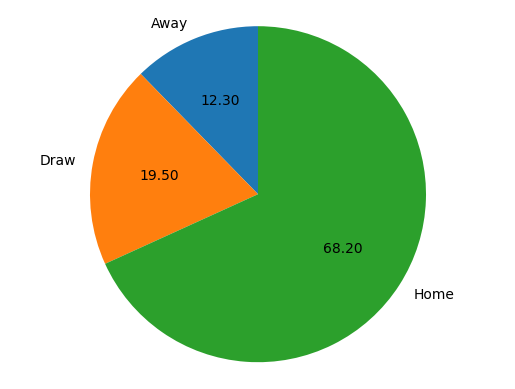

In [150]:
etiquetas = 'Away', 'Draw', 'Home'
figureObject, axesObject = plt.subplots()
axesObject.pie(pred1_number_probabilities, labels=etiquetas, autopct='%1.2f', startangle=90)
axesObject.axis('equal') # Aspect ratio equal means pie is a circle
plt.show()